# Flow Matching: Gaussian → Checkerboard

Compares six flow matching methods on the standard Gaussian → checkerboard task.
Each row shows one method; each column shows the sample distribution at a fixed time step t ∈ {0, 0.25, 0.5, 0.75, 1}.

**Methods:** OT-CFM · OT-Harmonic (ω=0.001, π/3, π/4, π/2) · Stochastic Interpolant + OT

In [8]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torchdyn.core import NeuralODE

from torchlfm.conditional_flow_matching import (
    ExactOptimalTransportConditionalFlowMatcher,
    ExactOptimalTransportHarmonicConditionalFlowMatcher,
    VariancePreservingConditionalFlowMatcher,
)
from torchlfm.optimal_transport import OTPlanSampler, wasserstein
from torchlfm.utils import sample_checkerboard

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [9]:
DIM        = 2
BATCH_SIZE = 4096
N_ITER     = 20_000
N_EVAL     = 50_000
LR         = 1e-3
HIDDEN_DIM = 512
T_VIS      = [0., 0.25, 0.5, 0.75, 1.]
HIST_BINS  = 300
HIST_RANGE = ((-5, 5), (-5, 5))

## Distributions

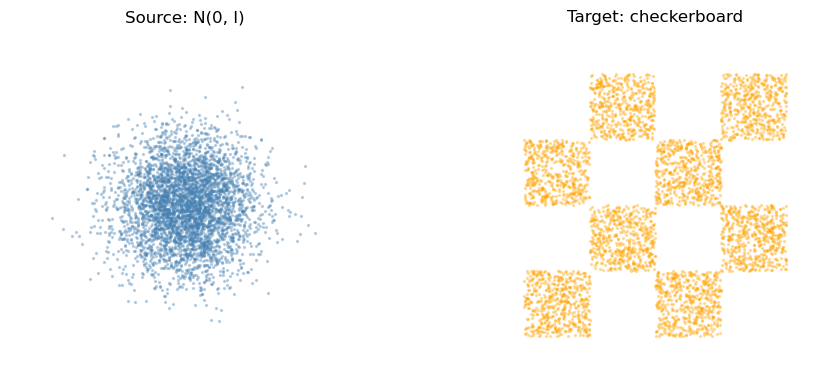

In [10]:
src = torch.randn(4096, DIM).numpy()
tgt = sample_checkerboard(4096).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(src[:, 0], src[:, 1], s=2, alpha=0.3, c="steelblue")
axes[0].set_title("Source: N(0, I)")
axes[0].set_xlim(-5, 5); axes[0].set_ylim(-5, 5)
axes[0].set_aspect("equal"); axes[0].axis("off")
axes[1].scatter(tgt[:, 0], tgt[:, 1], s=2, alpha=0.3, c="orange")
axes[1].set_title("Target: checkerboard")
axes[1].set_xlim(-8, 8); axes[1].set_ylim(-8, 8)
axes[1].set_aspect("equal"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## Methods

In [11]:
METHODS = {
    "OT-CFM": (
        ExactOptimalTransportConditionalFlowMatcher(sigma=0.0),
        None,
    ),
    "OT-Harmonic\nω=0.001": (
        ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=0.0, omega=0.001),
        None,
    ),
    "OT-Harmonic\nω=π/3": (
        ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=0.0, omega=math.pi / 3),
        None,
    ),
    "OT-Harmonic\nω=π/4": (
        ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=0.0, omega=math.pi / 4),
        None,
    ),
    "OT-Harmonic\nω=π/2": (
        ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=0.0, omega=math.pi / 2),
        None,
    ),
    "Stoch. Interpolant\n+ OT": (
        VariancePreservingConditionalFlowMatcher(sigma=0.0),
        OTPlanSampler(method="exact"),
    ),
}

## Train and generate

In [12]:
class Swish(nn.Module):
    def forward(self, x):
        return torch.sigmoid(x) * x


class MLP(nn.Module):
    def __init__(self, input_dim=2, time_dim=1, hidden_dim=512):
        super().__init__()
        self.input_dim = input_dim
        self.main = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x, t):
        t = t.reshape(-1, 1).expand(x.shape[0], 1).float()
        return self.main(torch.cat([x, t], dim=1))


class VFWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x):
        return self.model(x, t.expand(x.shape[0]))


def train(fm, ot_sampler):
    model = MLP(input_dim=DIM, time_dim=1, hidden_dim=HIDDEN_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    for k in range(N_ITER):
        optimizer.zero_grad()
        x0 = torch.randn(BATCH_SIZE, DIM).to(device)
        x1 = sample_checkerboard(BATCH_SIZE).to(device)
        if ot_sampler is not None:
            x0, x1 = ot_sampler.sample_plan(x0, x1)
        t, xt, ut = fm.sample_location_and_conditional_flow(x0, x1)
        vt = model(xt, t[:, None])
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        if (k + 1) % 2000 == 0:
            print(f"  iter {k+1:5d}  loss {loss.item():.4f}")
    return model


def generate_path(model):
    """Return trajectory snapshots at T_VIS time points. Shape: [len(T_VIS), N_EVAL, DIM]."""
    model.eval()
    node = NeuralODE(
        VFWrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )
    x0 = torch.randn(N_EVAL, DIM).to(device)
    t_span = torch.tensor(T_VIS, device=device)
    with torch.no_grad():
        traj = node.trajectory(x0, t_span=t_span)
    return traj.cpu()

In [13]:
results = {}  # name -> {"traj": [T, N, 2], "w2": float}

for name, (fm, ot_sampler) in METHODS.items():
    label = name.replace("\n", " ")
    print(f"\n=== {label} ===")
    model = train(fm, ot_sampler)
    traj = generate_path(model)
    w2 = wasserstein(traj[-1], sample_checkerboard(N_EVAL), power=2)
    print(f"  W\u2082 = {w2:.4f}")
    results[name] = {"traj": traj, "w2": w2}


=== OT-CFM ===


/opt/miniconda3/envs/diffusion/lib/python3.11/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


KeyboardInterrupt: 

## Sampling paths

In [ ]:
n_times = len(T_VIS)

for name, data in results.items():
    traj = data["traj"]   # [5, N_EVAL, 2]
    w2   = data["w2"]
    label = name.replace("\n", " ")

    fig, axes = plt.subplots(1, n_times, figsize=(5 * n_times, 4))

    for col, t_val in enumerate(T_VIS):
        ax  = axes[col]
        pts = traj[col].numpy()

        # first pass to get counts for normalization
        H, xedges, yedges, _ = ax.hist2d(
            pts[:, 0], pts[:, 1],
            bins=HIST_BINS, range=HIST_RANGE,
        )
        ax.cla()

        cmax = float(torch.quantile(torch.from_numpy(H), 0.99))
        norm = plt.Normalize(vmin=0, vmax=max(cmax, 1e-6))

        ax.hist2d(
            pts[:, 0], pts[:, 1],
            bins=HIST_BINS, range=HIST_RANGE,
            norm=norm, cmap="viridis",
        )
        ax.set_aspect("equal")
        ax.axis("off")

        ax.set_title(f"t = {t_val:.2f}", fontsize=11)

    # label on the leftmost panel
    axes[0].set_ylabel(f"{label}\nW₂={w2:.3f}", fontsize=9, labelpad=4)
    axes[0].axis("on")
    axes[0].set_yticks([])
    axes[0].set_xticks([])
    for spine in axes[0].spines.values():
        spine.set_visible(False)

    fig.suptitle(
        f"Gaussian → Checkerboard: {label}  (W₂ = {w2:.3f})",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()